In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [11]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================================
# 1. CLASS ĐỌC DỮ LIỆU ĐƯỢC THIẾT KẾ RIÊNG CHO CELEBA-SPOOF
# =====================================================================
class CelebASpoofDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_samples=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # Duyệt qua từng thư mục ID (ví dụ: 10001, 10006,...)
        for person_id in os.listdir(root_dir):
            person_path = os.path.join(root_dir, person_id)
            if not os.path.isdir(person_path): continue
            
            # Đọc ảnh Live (Nhãn 1)
            live_path = os.path.join(person_path, 'live')
            if os.path.exists(live_path):
                for img in os.listdir(live_path):
                    if img.endswith(('.jpg', '.png', '.jpeg')):
                        self.image_paths.append(os.path.join(live_path, img))
                        self.labels.append(1) # 1 = Người thật
                        
            # Đọc ảnh Spoof (Nhãn 0)
            spoof_path = os.path.join(person_path, 'spoof')
            if os.path.exists(spoof_path):
                for img in os.listdir(spoof_path):
                    if img.endswith(('.jpg', '.png', '.jpeg')):
                        self.image_paths.append(os.path.join(spoof_path, img))
                        self.labels.append(0) # 0 = Giả mạo
        
        # Lấy một lượng nhỏ dữ liệu để test code cho nhanh (Nếu cần)
        if max_samples:
            self.image_paths = self.image_paths[:max_samples]
            self.labels = self.labels[:max_samples]
            
        print(f"Đã nạp {len(self.image_paths)} ảnh từ thư mục {root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [17]:
# =====================================================================
# 2. CẤU HÌNH ĐƯỜNG DẪN VÀ KHỞI TẠO MÔ HÌNH
# =====================================================================
# Thay thế đường dẫn này bằng đường dẫn thực tế bạn thấy ở hàm os.walk
BASE_PATH = '/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/Data'
TRAIN_DIR = os.path.join(BASE_PATH, 'train') # Có thể đổi thành 'test' nếu bộ dataset không có folder train
TEST_DIR = os.path.join(BASE_PATH, 'test')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Mẹo: Đặt max_samples=2000 để chạy test cho nhanh xem code có lỗi không. 
# Khi báo cáo thật thì bỏ tham số này đi để train toàn bộ dữ liệu.
train_dataset = CelebASpoofDataset(root_dir=TRAIN_DIR, transform=transform, max_samples=10000)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Khởi tạo MobileNetV2
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Đã nạp 10000 ảnh từ thư mục /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/Data/train


Bắt đầu huấn luyện trên cuda...
Epoch [1/10] - Loss: 0.1060 | Accuracy: 0.9709 | Precision: 0.9673 | Recall: 0.9465 | F1-Score: 0.9568
Epoch [2/10] - Loss: 0.0134 | Accuracy: 0.9971 | Precision: 0.9973 | Recall: 0.9941 | F1-Score: 0.9957
Epoch [3/10] - Loss: 0.0047 | Accuracy: 0.9992 | Precision: 0.9997 | Recall: 0.9979 | F1-Score: 0.9988
Epoch [4/10] - Loss: 0.0072 | Accuracy: 0.9981 | Precision: 0.9974 | Recall: 0.9971 | F1-Score: 0.9972
Epoch [5/10] - Loss: 0.0024 | Accuracy: 0.9997 | Precision: 0.9997 | Recall: 0.9994 | F1-Score: 0.9996
Epoch [6/10] - Loss: 0.0046 | Accuracy: 0.9986 | Precision: 0.9976 | Recall: 0.9982 | F1-Score: 0.9979
Epoch [7/10] - Loss: 0.0035 | Accuracy: 0.9991 | Precision: 0.9985 | Recall: 0.9988 | F1-Score: 0.9987
Epoch [8/10] - Loss: 0.0015 | Accuracy: 0.9998 | Precision: 0.9997 | Recall: 0.9997 | F1-Score: 0.9997
Epoch [9/10] - Loss: 0.0026 | Accuracy: 0.9990 | Precision: 0.9988 | Recall: 0.9982 | F1-Score: 0.9985
Epoch [10/10] - Loss: 0.0007 | Accuracy: 

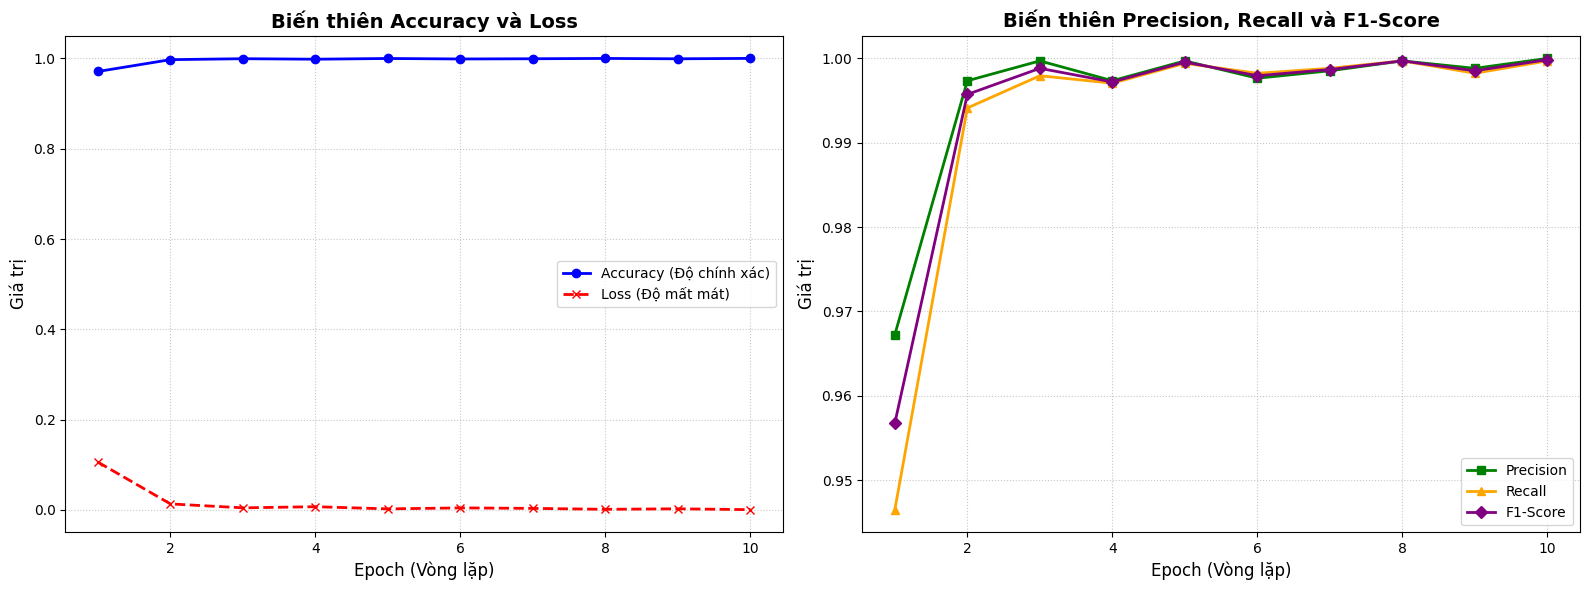

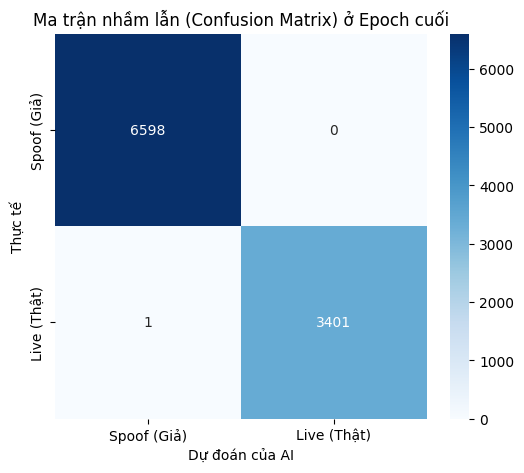

Đã lưu mô hình thành công tại: /kaggle/working/anti_spoof_cnn.pth


In [18]:
# =====================================================================
# 3. HUẤN LUYỆN, ĐÁNH GIÁ VÀ VẼ BIỂU ĐỒ ĐỒ THỊ CHỈ SỐ
# =====================================================================
num_epochs = 10
print(f"Bắt đầu huấn luyện trên {device}...")

# --- KHỞI TẠO CÁC MẢNG LƯU LỊCH SỬ ĐỂ VẼ BIỂU ĐỒ ---
history_epochs = []
history_losses = []
history_accuracies = []
history_precisions = []
history_recalls = []
history_f1_scores = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    # Các mảng lưu lại nhãn thật và nhãn dự đoán của epoch hiện tại
    all_preds = []
    all_labels = []
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        # Lấy dự đoán (0 hoặc 1)
        _, predicted = outputs.max(1)
        
        # Lưu vào mảng
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    epoch_loss = running_loss / len(train_dataset)
    
    # --- TÍNH TOÁN CÁC CHỈ SỐ ---
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    # --- LƯU GIÁ TRỊ VÀO LỊCH SỬ ---
    history_epochs.append(epoch + 1)
    history_losses.append(epoch_loss)
    history_accuracies.append(acc)
    history_precisions.append(prec)
    history_recalls.append(rec)
    history_f1_scores.append(f1)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} | Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

print("\n--- Huấn luyện hoàn tất! Đang tạo các báo cáo đồ thị... ---")

# =====================================================================
# PHẦN VẼ 2 BIỂU ĐỒ CHỈ SỐ (LỌC THEO LỊCH SỬ)
# =====================================================================
plt.figure(figsize=(16, 6))

# Đồ thị 1: Accuracy & Loss
plt.subplot(1, 2, 1)
plt.plot(history_epochs, history_accuracies, label='Accuracy (Độ chính xác)', color='blue', marker='o', linewidth=2)
plt.plot(history_epochs, history_losses, label='Loss (Độ mất mát)', color='red', marker='x', linewidth=2, linestyle='--')
plt.title('Biến thiên Accuracy và Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch (Vòng lặp)', fontsize=12)
plt.ylabel('Giá trị', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)

# Đồ thị 2: Precision, Recall & F1-Score
plt.subplot(1, 2, 2)
plt.plot(history_epochs, history_precisions, label='Precision', color='green', marker='s', linewidth=2)
plt.plot(history_epochs, history_recalls, label='Recall', color='orange', marker='^', linewidth=2)
plt.plot(history_epochs, history_f1_scores, label='F1-Score', color='purple', marker='D', linewidth=2)
plt.title('Biến thiên Precision, Recall và F1-Score', fontsize=14, fontweight='bold')
plt.xlabel('Epoch (Vòng lặp)', fontsize=12)
plt.ylabel('Giá trị', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# =====================================================================
# PHẦN VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# =====================================================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Spoof (Giả)', 'Live (Thật)'], yticklabels=['Spoof (Giả)', 'Live (Thật)'])
plt.xlabel('Dự đoán của AI')
plt.ylabel('Thực tế')
plt.title('Ma trận nhầm lẫn (Confusion Matrix) ở Epoch cuối')
plt.show()

# =====================================================================
# LƯU MÔ HÌNH VÀO FILE LOCAL CỦA KAGGLE
# =====================================================================
save_path = '/kaggle/working/anti_spoof_cnn.pth'
torch.save(model.state_dict(), save_path)
print(f"Đã lưu mô hình thành công tại: {save_path}")

✅ Kết quả: ĐÂY LÀ KHUÔN MẶT THẬT (LIVE)


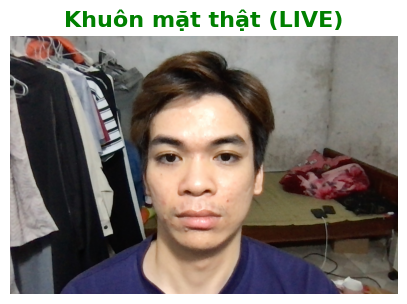

In [21]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt # Thêm thư viện vẽ ảnh

# 1. KHỞI TẠO LẠI KIẾN TRÚC MÔ HÌNH (Phải giống hệt lúc huấn luyện)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.mobilenet_v2(weights=None) 
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2) 

# 2. LOAD TRỌNG SỐ TỪ FILE ĐÃ HUẤN LUYỆN
model_path = 'anti_spoof_cnn.pth' 
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval() 

# 3. CHUẨN BỊ ẢNH ĐẦU VÀO
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

image_path = '/kaggle/input/datasets/snthntrung/nh-tt/anh test .jpg' # Tên file ảnh bạn đã up lên
image = Image.open(image_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device) 

# 4. DỰ ĐOÁN
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)

    # Decode nhãn (0: Spoof, 1: Live)
    if predicted.item() == 1:
        result_text = "Khuôn mặt thật (LIVE)"
        color = 'green' # Chữ màu xanh cho ảnh thật
        print("✅ Kết quả: ĐÂY LÀ KHUÔN MẶT THẬT (LIVE)")
    else:
        result_text = "Phát hiện giả mạo (SPOOF)"
        color = 'red'   # Chữ màu đỏ cho ảnh giả
        print("❌ Kết quả: PHÁT HIỆN GIẢ MẠO (SPOOF)")

# 5. HIỂN THỊ ẢNH VÀ KẾT QUẢ TRÊN MÀN HÌNH
plt.figure(figsize=(5, 5))
plt.imshow(image) # Hiển thị ảnh gốc chưa qua biến đổi
plt.title(result_text, color=color, fontsize=16, fontweight='bold')
plt.axis('off') # Ẩn các trục tọa độ x, y cho đẹp
plt.show()